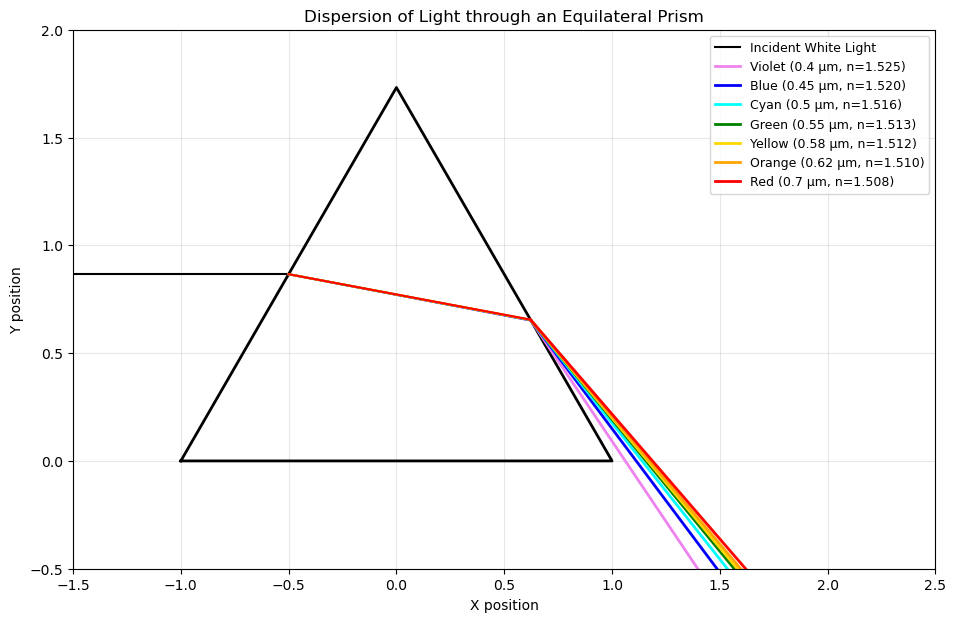

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define physics parameters
wavelengths = {
    'Violet': 0.40, 'Blue': 0.45, 'Cyan': 0.50, 'Green': 0.55, 
    'Yellow': 0.58, 'Orange': 0.62, 'Red': 0.70
}
# We use 'gold' instead of 'yellow' for better visibility on a white background
colors = ['violet', 'blue', 'cyan', 'green', 'gold', 'orange', 'red']

# Refractive index as a function of wavelength (in microns)
def calc_n(lam):
    return 1.50 + 0.004 / (lam**2)

# 2. Setup the prism geometry
A = np.radians(60)         # Prism apex angle
theta_i1 = np.radians(30)  # Incident angle relative to the left face normal
h = np.sqrt(3) / 2         # Height where the incident ray strikes (halfway up)
x1, y1 = -0.5, h           # (x,y) coordinates of the first strike

# Initialize the plot
plt.figure(figsize=(12, 7))

# Draw the equilateral prism: Base from x=-1 to 1, apex at (0, sqrt(3))
prism_x = [-1, 1, 0, -1]
prism_y = [0, 0, np.sqrt(3), 0]
plt.plot(prism_x, prism_y, 'k-', lw=2)

# Draw the incoming white light ray
plt.plot([-2, x1], [y1, y1], 'k-', lw=1.5, label='Incident White Light')

# 3. Ray tracing loop
for i, (name, lam) in enumerate(wavelengths.items()):
    n = calc_n(lam)
    
    # --- Interface 1: Air to Glass ---
    # Snell's Law: 1.0 * sin(theta_i1) = n * sin(theta_t1)
    theta_t1 = np.arcsin(np.sin(theta_i1) / n)
    
    # Calculate ray trajectory absolute angle inside the prism
    alpha_1 = np.radians(-30) + theta_t1
    
    # Find intersection point (x2, y2) on the right face: y = -sqrt(3)x + sqrt(3)
    x2 = (np.sqrt(3) + x1 * np.tan(alpha_1) - y1) / (np.tan(alpha_1) + np.sqrt(3))
    y2 = -np.sqrt(3) * x2 + np.sqrt(3)
    
    # --- Interface 2: Glass to Air ---
    theta_i2 = A - theta_t1
    # Snell's Law: n * sin(theta_i2) = 1.0 * sin(theta_t2)
    theta_t2 = np.arcsin(n * np.sin(theta_i2))
    
    # Calculate final exiting ray absolute angle
    alpha_2 = np.radians(30) - theta_t2
    
    # Calculate a final point (x3, y3) far outside the prism for drawing the line
    x3 = 3
    y3 = y2 + np.tan(alpha_2) * (x3 - x2)
    
    # Plot the ray inside the prism
    plt.plot([x1, x2], [y1, y2], color=colors[i], lw=1.5)
    # Plot the ray exiting the prism
    plt.plot([x2, x3], [y2, y3], color=colors[i], lw=2, label=f'{name} ({lam} µm, n={n:.3f})')

# 4. Plot formatting
plt.xlim(-1.5, 2.5)
plt.ylim(-0.5, 2.0)
plt.gca().set_aspect('equal', adjustable='box')
plt.title('Dispersion of Light through an Equilateral Prism')
plt.xlabel('X position')
plt.ylabel('Y position')
plt.legend(loc='upper right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup the geometry (same as the main model)
A = np.radians(60)         
theta_i1 = np.radians(30)  
h = np.sqrt(3) / 2         
x1, y1 = -0.5, h           

# 2. Force the refractive index to equal air (1.0)
n_test = 1.0

# --- Interface 1 ---
theta_t1 = np.arcsin(np.sin(theta_i1) / n_test)
alpha_1 = np.radians(-30) + theta_t1

# Calculate intersection point (x2, y2)
x2 = (np.sqrt(3) + x1 * np.tan(alpha_1) - y1) / (np.tan(alpha_1) + np.sqrt(3))
y2 = -np.sqrt(3) * x2 + np.sqrt(3)

# --- Interface 2 ---
theta_i2 = A - theta_t1
theta_t2 = np.arcsin(n_test * np.sin(theta_i2))
alpha_2 = np.radians(30) - theta_t2

# Calculate final point (x3, y3)
x3 = 3
y3 = y2 + np.tan(alpha_2) * (x3 - x2)

# 3. Print the verification results
print(f"Incident Ray Height (y1): {y1:.5f}")
print(f"Internal Ray Height (y2): {y2:.5f}")
print(f"Exiting Ray Height  (y3): {y3:.5f}")
print("-" * 30)
if np.isclose(y1, y2) and np.isclose(y2, y3):
    print("VERIFICATION PASSED: The ray traveled in a perfectly straight horizontal line.")
else:
    print("VERIFICATION FAILED: The ray deviated.")

Incident Ray Height (y1): 0.86603
Internal Ray Height (y2): 0.86603
Exiting Ray Height  (y3): 0.86603
------------------------------
VERIFICATION PASSED: The ray traveled in a perfectly straight horizontal line.
